In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

/tmp/ipykernel_3829349/4169949440.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in subset.groupby('name'):
/tmp/ipykernel_3829349/4169949440.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in subset.groupby('name'):
/tmp/ipykernel_3829349/4169949440.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in subset.groupby('name'):
/tmp/ipykernel_3829349/4169949440.

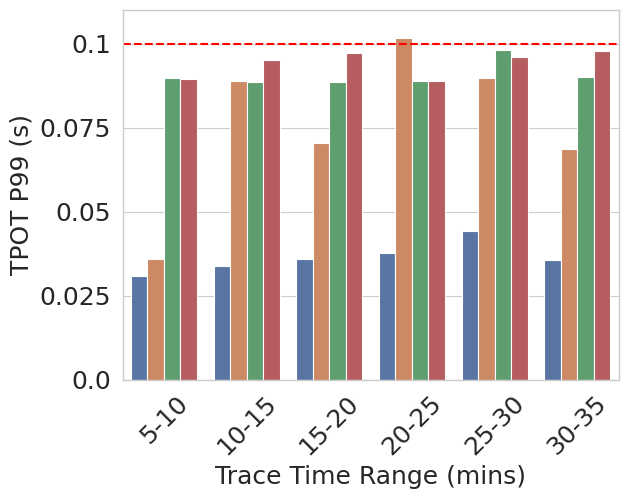

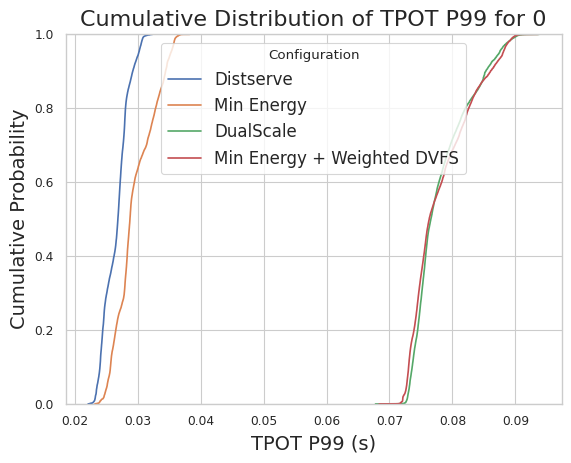

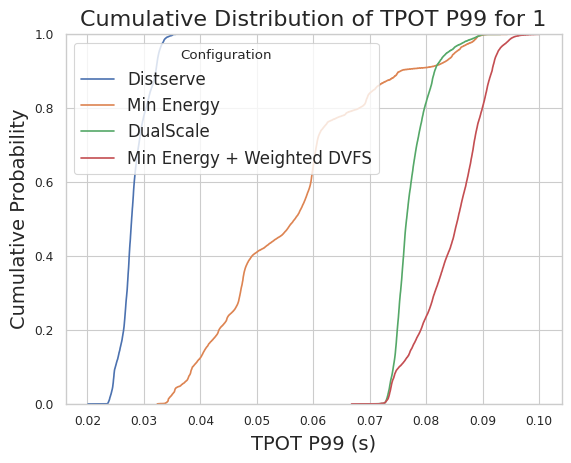

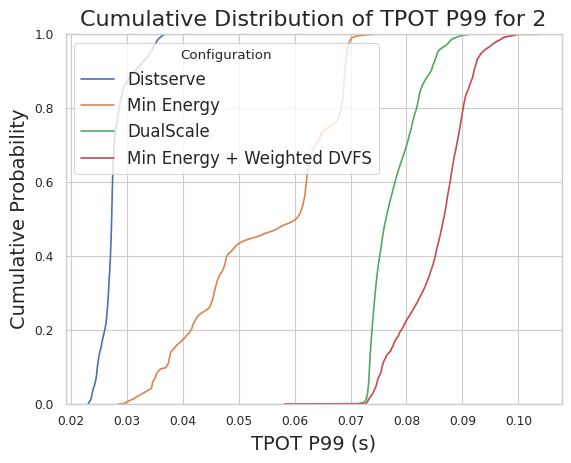

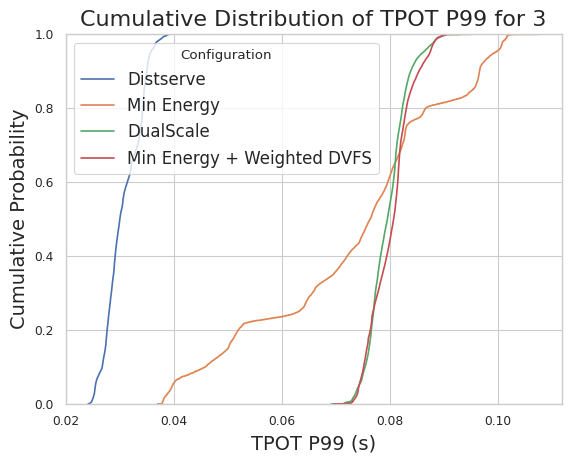

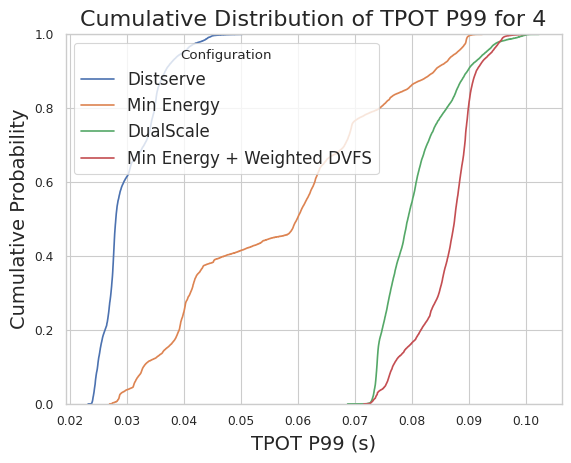

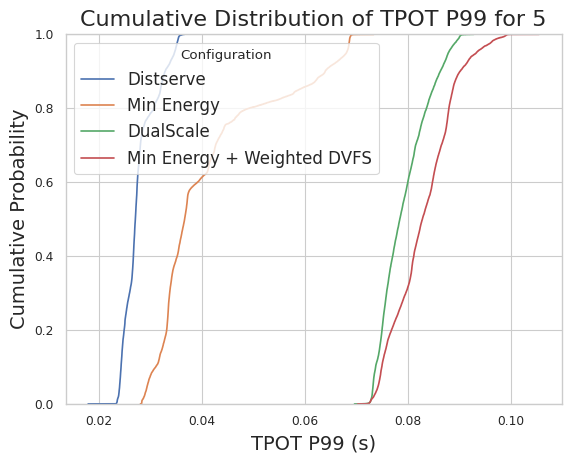

In [2]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'Min Energy 85',
    'OURS_R5_JAN3_REAL_P85_5': 'Min Energy 70',
    'OURS_R5_JAN3_REAL_P85_4': 'Min Energy 55',
    'OURS_R5_JAN3_REAL_P85_3': 'Min Energy 40',
    'OURS_R5_JAN3_REAL_P85_2': 'Min Energy 25',
    'OURS_R5_JAN3_REAL_P85_1': 'Min Energy 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS': 'DualScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS': 'DualScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS': 'DualScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS': 'DualScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS': 'DualScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS': 'DualScale 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'Min Energy + Weighted DVFS 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'Min Energy + Weighted DVFS 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'Min Energy + Weighted DVFS 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'Min Energy + Weighted DVFS 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'Min Energy + Weighted DVFS 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'Min Energy + Weighted DVFS 10'
}

df_results["path"] = Path(path).parent / df_results['expr_dir']

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'Min Energy', 'DualScale', 'Min Energy + Weighted DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])


sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('TPOT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.11)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=18)
ax.legend_.remove()

# Plot CDF for each cluster of bars
unique_rps = df_results['rps'].unique()

for i, rps in enumerate(unique_rps):
    plt.figure()
    subset = df_results[df_results['rps'] == rps]
    for name, group in subset.groupby('name'):
        for _, row in group.iterrows():
            p = Path(row['path']) / "tpot.csv"
            data = pd.read_csv(p)
            sns.ecdfplot(data=data, x='tpot_s', label=name)
    
    # Customize the plot
    plt.title(f'Cumulative Distribution of TPOT P99 for {i}', fontsize=16)
    plt.xlabel('TPOT P99 (s)', fontsize=14)
    plt.ylabel('Cumulative Probability', fontsize=14)
    plt.legend(title='Configuration', fontsize=12)
    plt.grid(True)


In [3]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'Min Energy 85',
    'OURS_R5_JAN3_OLD_P90_5': 'Min Energy 70',
    'OURS_R5_JAN3_OLD_P90_4': 'Min Energy 55',
    'OURS_R5_JAN3_OLD_P90_3': 'Min Energy 40',
    'OURS_R5_JAN3_OLD_P90_2': 'Min Energy 25',
    'OURS_R5_JAN3_OLD_P90_1': 'Min Energy 10',
    'OURS_R5_JAN3_OLD_P90_6_DVFS': 'DualScale 85',
    'OURS_R5_JAN3_OLD_P90_5_DVFS': 'DualScale 70',
    'OURS_R5_JAN3_OLD_P90_4_DVFS': 'DualScale 55',
    'OURS_R5_JAN3_OLD_P90_3_DVFS': 'DualScale 40',
    'OURS_R5_JAN3_OLD_P90_2_DVFS': 'DualScale 25',
    'OURS_R5_JAN3_OLD_P90_1_DVFS': 'DualScale 10'
}

df_results["path"] = Path(path).parent / df_results['expr_dir']

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'Min Energy', 'DualScale', 'Min Energy + Weighted DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])


sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('TPOT P99 (s)', fontsize=18)
ax.set_ylim(0, 0.11)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=18)
ax.legend_.remove()

# Plot CDF for each cluster of bars
unique_rps = df_results['rps'].unique()

for i, rps in enumerate(unique_rps):
    plt.figure()
    subset = df_results[df_results['rps'] == rps]
    for name, group in subset.groupby('name'):
        for _, row in group.iterrows():
            p = Path(row['path']) / "tpot.csv"
            data = pd.read_csv(p)
            sns.ecdfplot(data=data, x='tpot_s', label=name)
    
    # Customize the plot
    plt.title(f'Cumulative Distribution of TPOT P99 for {i}', fontsize=16)
    plt.xlabel('TPOT P99 (s)', fontsize=14)
    plt.ylabel('Cumulative Probability', fontsize=14)
    plt.legend(title='Configuration', fontsize=12)
    plt.grid(True)


ValueError: cannot convert float NaN to integer